# Notebook 4 — Longitudinal Causal Effect Estimation (Age ≥ 65)

This notebook estimates the **12-month causal effect** of being **exposed to the algorithmic social prescription recommendation** (intervention) versus **usual referral** (comparator) using propensity-score-based methods.

**Key distinction**
- Recommendation algorithm: rule-based targeting & service matching (Notebook 2)
- Causal matching / causal inference: estimating impact with covariate balance (Notebook 4)

**Inputs**
- `../data_processed/notebook2_recommendations.csv`
- `../data_processed/notebook3_person_level_outcomes.csv`
- (optional) `../data_processed/notebook1_baseline_analytic.csv`

**Outputs**
- `../data_processed/notebook4_analysis_dataset.csv`
- `../data_processed/notebook4_matched_dataset.csv`
- `../data_processed/notebook4_balance_diagnostics.csv`
- `../data_processed/notebook4_causal_effect_results.csv`
- Figures: propensity distribution, Love plot, effect plot

**Population**
- Age ≥ 65 (aligned with capstone requirement)

**Citations**
This project uses the RAND HRS Longitudinal File documentation as the primary data reference.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import NearestNeighbors

SEED = 42
np.random.seed(SEED)

DATA_DIR = "../data_processed"
FIG_DIR = "../figures"
os.makedirs(FIG_DIR, exist_ok=True)

FILE_RECO = os.path.join(DATA_DIR, "notebook2_recommendations.csv")
FILE_BASE = os.path.join(DATA_DIR, "notebook1_baseline_analytic.csv")
FILE_OUTC = os.path.join(DATA_DIR, "notebook3_person_level_outcomes.csv")

print(FILE_RECO, os.path.exists(FILE_RECO))
print(FILE_BASE, os.path.exists(FILE_BASE))
print(FILE_OUTC, os.path.exists(FILE_OUTC))

../data_processed\notebook2_recommendations.csv True
../data_processed\notebook1_baseline_analytic.csv True
../data_processed\notebook3_person_level_outcomes.csv True


In [3]:
# ============================
# Figure Saving Configuration
# ============================

import os

FIG_DIR = "../figures"
os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(name):
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, name),
                dpi=150,
                bbox_inches="tight")

In [4]:
import os
import numpy as np
import pandas as pd

DATA_DIR = "../data_processed"
PANEL_FILE = os.path.join(DATA_DIR, "notebook0_clean_panel.csv")
OUT_OUTCOME = os.path.join(DATA_DIR, "notebook3_person_level_outcomes.csv")

panel = pd.read_csv(PANEL_FILE)
if "HHIDPN" in panel.columns and "hhidpn" not in panel.columns:
    panel = panel.rename(columns={"HHIDPN":"hhidpn"})
panel["hhidpn"] = panel["hhidpn"].astype(str)

# time
if "wave" not in panel.columns:
    raise ValueError("wave not found in panel.")
panel["wave"] = pd.to_numeric(panel["wave"], errors="coerce")
panel = panel.dropna(subset=["wave"]).copy()

# hosp
if "hosp" not in panel.columns:
    raise ValueError("hosp not found in panel.")
panel["hosp"] = pd.to_numeric(panel["hosp"], errors="coerce")

# ---- auto detect CESD column ----
cesd_candidates = ["cesd", "rcesd", "rcestot", "cesd_score", "cesd_total", "depressed", "depr_score"]
cesd_col = None
for c in cesd_candidates:
    if c in panel.columns:
        cesd_col = c
        break

# fallback: fuzzy contains
if cesd_col is None:
    fuzzy = [c for c in panel.columns if "ces" in c.lower() or "cesd" in c.lower()]
    if len(fuzzy) > 0:
        cesd_col = fuzzy[0]

print("Detected CESD column:", cesd_col)

if cesd_col is not None:
    panel[cesd_col] = pd.to_numeric(panel[cesd_col], errors="coerce")

# baseline wave per person
baseline = panel.groupby("hhidpn")["wave"].min().rename("baseline_time").reset_index()
panel = panel.merge(baseline, on="hhidpn", how="left")

# next wave (baseline+1)
panel["in_12m"] = (panel["wave"] == panel["baseline_time"] + 1).astype(int)

# primary outcome: any hosp in next wave
outcome_df = (
    panel[panel["in_12m"] == 1]
    .groupby("hhidpn")
    .agg(adm_any_next12m=("hosp", lambda x: int(np.nanmax(x) > 0) if len(x.dropna()) else np.nan))
    .reset_index()
)

# =========================
# CESD change (robust version)
# =========================

if cesd_col is not None:

    # 只保留有 CESD 值的记录
    panel_nonmiss = panel.dropna(subset=[cesd_col]).copy()

    # 每个人第一次有 CESD 的 wave
    cesd_first_wave = (
        panel_nonmiss.groupby("hhidpn")["wave"]
        .min()
        .rename("cesd_base_wave")
        .reset_index()
    )

    panel = panel.merge(cesd_first_wave, on="hhidpn", how="left")

    # baseline CESD
    cesd_base = (
        panel[panel["wave"] == panel["cesd_base_wave"]]
        .groupby("hhidpn")[cesd_col]
        .mean()
        .rename("cesd_base")
        .reset_index()
    )

    # 下一波 CESD（base_wave + 1）
    panel["cesd_in_12m"] = (
        panel["wave"] == panel["cesd_base_wave"] + 1
    ).astype(int)

    cesd_next = (
        panel[panel["cesd_in_12m"] == 1]
        .groupby("hhidpn")[cesd_col]
        .mean()
        .rename("cesd_next")
        .reset_index()
    )

    outcome_df = (
        outcome_df
        .merge(cesd_base, on="hhidpn", how="left")
        .merge(cesd_next, on="hhidpn", how="left")
    )

    outcome_df["cesd_change_next12m"] = (
        outcome_df["cesd_next"] - outcome_df["cesd_base"]
    )

    print("CESD change missing:",
          outcome_df["cesd_change_next12m"].isna().mean())

else:
    outcome_df["cesd_change_next12m"] = np.nan
    print("No CESD column found.")

# baseline time
outcome_df = outcome_df.merge(baseline, on="hhidpn", how="left")

print(outcome_df.head())
outcome_df.to_csv(OUT_OUTCOME, index=False)
print("Saved:", OUT_OUTCOME)

Detected CESD column: cesd
CESD change missing: 0.2381836671530265
     hhidpn  adm_any_next12m  cesd_base  cesd_next  cesd_change_next12m  \
0  10001010              0.0        4.0        1.0                 -3.0   
1  10003020              0.0        NaN        NaN                  NaN   
2  10003030              0.0        1.0        3.0                  2.0   
3  10004010              0.0        1.0        0.0                 -1.0   
4  10004040              0.0        0.0        0.0                  0.0   

   baseline_time  
0              1  
1              1  
2              1  
3              1  
4              1  
Saved: ../data_processed\notebook3_person_level_outcomes.csv


In [5]:
reco = pd.read_csv(FILE_RECO)
base = pd.read_csv(FILE_BASE)
outc = pd.read_csv(FILE_OUTC)

# normalize id
for d in [reco, base, outc]:
    if "HHIDPN" in d.columns and "hhidpn" not in d.columns:
        d.rename(columns={"HHIDPN": "hhidpn"}, inplace=True)
    d["hhidpn"] = d["hhidpn"].astype(str)

df = reco.merge(base, on="hhidpn", how="left").merge(outc, on="hhidpn", how="left")

print("Final analysis df:", df.shape)
print("Columns sample:", df.columns.tolist()[:35])
df.head()

Final analysis df: (29371, 25)
Columns sample: ['hhidpn', 'risk_score', 'high_risk_x', 'top1', 'top2', 'top3', 'reco_list', 'reco_reason_list', 'has_specific_reco', 'intervention_exposed', 'comparator_usual_referral', 'wave', 'age', 'gender', 'edu_years', 'diabetes', 'adl_any', 'cesd', 'hosp', 'high_risk_y', 'adm_any_next12m', 'cesd_base', 'cesd_next', 'cesd_change_next12m', 'baseline_time']


,hhidpn,risk_score,high_risk_x,top1,top2,top3,reco_list,reco_reason_list,has_specific_reco,intervention_exposed,...,diabetes,adl_any,cesd,hosp,high_risk_y,adm_any_next12m,cesd_base,cesd_next,cesd_change_next12m,baseline_time
0,2010,0.166667,0,General community resource information,NaN,NaN,['General community resource information'],['Default / universal info (operationalises us...,0,0,...,0.0,0.0,1.0,0.0,0,0.0,0.0,2.0,2.0,1
1,3010,0.333333,0,Care coordination / follow-up,NaN,NaN,['Care coordination / follow-up'],['Post-discharge / care transition needs'],1,1,...,0.0,0.0,0.0,1.0,0,0.0,0.0,3.0,3.0,1
2,3020,0.333333,0,Care coordination / follow-up,NaN,NaN,['Care coordination / follow-up'],['Post-discharge / care transition needs'],1,1,...,0.0,0.0,0.0,1.0,0,1.0,0.0,1.0,1.0,1
3,10001010,0.333333,0,General community resource information,NaN,NaN,['General community resource information'],['Default / universal info (operationalises us...,0,0,...,0.0,0.0,1.0,0.0,0,0.0,4.0,1.0,-3.0,1
4,10003030,0.166667,0,General community resource information,NaN,NaN,['General community resource information'],['Default / universal info (operationalises us...,0,0,...,0.0,0.0,2.0,0.0,0,0.0,1.0,3.0,2.0,1


## Key Variable Definitions

| Variable | Definition | Source |
|----------|------------|--------|
| **Treatment Variables** |
| intervention_exposed | Whether received any specific recommendation | Notebook 2 |
| | (vs. general information only) | |
| **Outcome Variables** |
| adm_any_next12m | Any hospitalization in next wave | Notebook 0 panel |
| cesd_change_next12m | Follow-up CESD - Baseline CESD | Notebook 0 panel |
| **Covariates** |
| age | Baseline age | RAND HRS (r#agey_e) |
| gender | Sex (1=male, 2=female → encoded 0/1) | RAND HRS (ragender) |
| edu_years | Education years (categorical) | RAND HRS (raeduc) |
| cesd | Baseline CESD score (0-8) | RAND HRS (r#cesd) |
| adl_any | Any ADL difficulty | RAND HRS (r#adl5a) |
| diabetes | Has diabetes | RAND HRS (r#diab) |

**Note**: RAND HRS uses 8-item CESD; threshold ≥4 corresponds to clinically significant depressive symptoms.

In [6]:
def coerce_binary(s):
    if s.dtype == bool:
        return s.astype(int)
    if pd.api.types.is_numeric_dtype(s):
        return s
    ss = s.astype(str).str.strip().str.lower()
    mapping = {"1": 1, "0": 0, "yes": 1, "no": 0, "true": 1, "false": 0}
    return ss.map(mapping)

def standardized_mean_diff(df_t, df_c, col):
    xt = pd.to_numeric(df_t[col], errors="coerce")
    xc = pd.to_numeric(df_c[col], errors="coerce")
    mt, mc = xt.mean(), xc.mean()
    sd = np.sqrt((xt.var(ddof=1) + xc.var(ddof=1)) / 2)
    if sd == 0 or np.isnan(sd):
        return np.nan
    return (mt - mc) / sd

In [7]:
# ============================
# Define treatment as a POLICY THRESHOLD (minimal-change, better overlap)
# treatment = 1 if risk_score >= quantile threshold
# ============================

import numpy as np
import pandas as pd

# df should already contain: hhidpn, risk_score, outcome_primary, and covariates columns
assert "risk_score" in df.columns, "risk_score not found. Ensure Notebook2 output was merged into Notebook4 dataset."

# choose policy threshold: top 30% as treated (can change 0.7 to 0.6/0.8 for sensitivity)
q = 0.70
thr = df["risk_score"].quantile(q)

df = df.copy()
df["treatment"] = (df["risk_score"] >= thr).astype(int)

print(f"[Policy Treatment] risk_score threshold @ q={q}: {thr:.4f}")
print(df["treatment"].value_counts(dropna=False))

[Policy Treatment] risk_score threshold @ q=0.7: 0.5000
treatment
1    15323
0    14048
Name: count, dtype: int64


In [8]:
age_candidates = [c for c in ["age", "age_years", "baseline_age", "agem_b"] if c in df.columns]
age_col = age_candidates[0] if age_candidates else None

if age_col is None:
    print("WARNING: no age column found; skipping age>=65 filter.")
else:
    df[age_col] = pd.to_numeric(df[age_col], errors="coerce")
    df = df[df[age_col] >= 65].copy()
    print(f"Filtered age>=65 using '{age_col}', df shape:", df.shape)

Filtered age>=65 using 'age', df shape: (29371, 26)


In [9]:
# ============================
# Robust setup: ensure ID / treatment / outcome_primary exist + build work_cc safely
# ============================

import pandas as pd
import numpy as np

def find_col(df, candidates):
    cols = {c.lower().strip(): c for c in df.columns}
    for cand in candidates:
        key = cand.lower().strip()
        if key in cols:
            return cols[key]
    return None

df = df.copy()

# --- 1) Ensure ID column -> hhidpn ---
id_col = find_col(df, ["hhidpn", "HHIDPN", "hhid_pn", "hhidpn_id", "id"])
if id_col is None:
    # fallback: sometimes id is split; if you have HHID and PN, you can reconstruct
    hhid = find_col(df, ["hhid", "HHID"])
    pn   = find_col(df, ["pn", "PN"])
    if hhid is not None and pn is not None:
        df["hhidpn"] = df[hhid].astype(str) + "_" + df[pn].astype(str)
        id_col = "hhidpn"

if id_col is None:
    raise KeyError("Cannot find an ID column. Expected something like 'hhidpn' (or 'hhid'+'pn').")

if id_col != "hhidpn":
    df = df.rename(columns={id_col: "hhidpn"})

# --- 2) Ensure treatment exists ---
if "treatment" not in df.columns:
    raise KeyError("Column 'treatment' not found. Define df['treatment'] BEFORE this cell.")

# --- 3) Ensure outcome_primary exists (auto-map to hosp/cesd/etc) ---
if "outcome_primary" not in df.columns:
    # pick the outcome you are estimating in Notebook4 (most common = hosp)
    outcome_guess = find_col(df, ["hosp", "hospital_any", "hospital", "rwhosp", "cesd", "cesd_score", "cesd_total"])
    if outcome_guess is None:
        raise KeyError(
            "Column 'outcome_primary' not found and no known outcome column detected.\n"
            "Add/rename your outcome column to df['outcome_primary'] before this cell."
        )
    df = df.rename(columns={outcome_guess: "outcome_primary"})
    print(f"[Auto-map] outcome_primary <- {outcome_guess}")

# --- 4) Covariates selection ---
cov_candidate_groups = {
    "demo_age": ["age", "age_years", "baseline_age"],
    "demo_sex": ["sex_binary", "sex", "gender"],
    "ses_edu":  ["edu_years", "education_years"],
    "func_adl": ["adl_any", "iadl_any"],
    "chronic":  ["diabetes", "hypertension", "heart", "stroke"],
    "mental":   ["cesd", "cesd_score", "cesd_total"],
}

covariates = []
for _, cands in cov_candidate_groups.items():
    col = find_col(df, cands)
    if col is not None:
        covariates.append(col)

# unique & drop any accidental duplicates
covariates = list(dict.fromkeys(covariates))
print("Initial covariates:", covariates)

# --- 5) Build work dataframe safely (print missing columns if any) ---
need_cols = ["hhidpn", "treatment", "outcome_primary"] + covariates
missing = [c for c in need_cols if c not in df.columns]
if missing:
    print("❌ Missing columns in df:", missing)
    print("Available columns sample:", list(df.columns)[:50])
    raise KeyError("Some required columns are missing (see list above). Fix mapping/renaming then rerun.")

work = df[need_cols].copy()

# numeric coercion
for c in covariates + ["outcome_primary"]:
    work[c] = pd.to_numeric(work[c], errors="coerce")

work_cc = work.dropna(subset=["treatment", "outcome_primary"] + covariates).copy()
print("Complete-case rows:", work_cc.shape[0], "/", work.shape[0])

# --- 6) Drop covariates constant within treated OR control (prevents NaN SMD) ---
keep, dropped = [], []
for c in covariates:
    vt = work_cc.loc[work_cc["treatment"]==1, c].nunique(dropna=True)
    vc = work_cc.loc[work_cc["treatment"]==0, c].nunique(dropna=True)
    if vt <= 1 or vc <= 1:
        dropped.append((c, vt, vc))
    else:
        keep.append(c)

if dropped:
    print("Dropping near-constant covariates (nunique treated/control):")
    for c, vt, vc in dropped:
        print(f" - {c}: treated={vt}, control={vc}")

covariates = keep
print("Final covariates used:", covariates)

# Re-slice
work_cc = work_cc[["hhidpn", "treatment", "outcome_primary"] + covariates].copy()

[Auto-map] outcome_primary <- hosp
Initial covariates: ['age', 'gender', 'edu_years', 'adl_any', 'diabetes', 'cesd']
Complete-case rows: 23580 / 29371
Final covariates used: ['age', 'gender', 'edu_years', 'adl_any', 'diabetes', 'cesd']


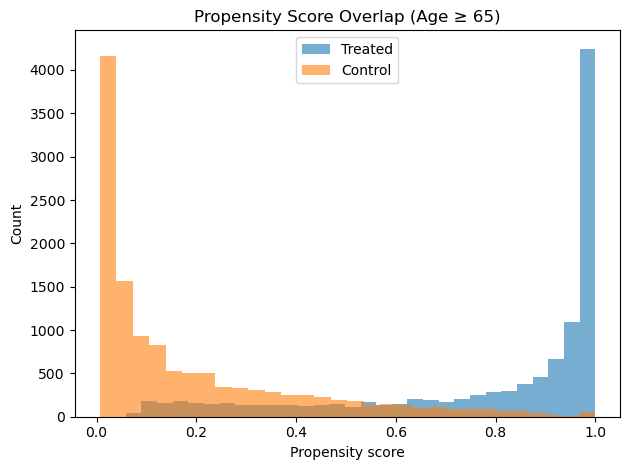

In [10]:
X = work_cc[covariates].values
t = work_cc["treatment"].astype(int).values

ps_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=2000, random_state=SEED))
])

ps_pipe.fit(X, t)
work_cc["propensity_score"] = ps_pipe.predict_proba(X)[:, 1]

plt.figure()
plt.hist(work_cc.loc[work_cc["treatment"]==1, "propensity_score"], bins=30, alpha=0.6, label="Treated")
plt.hist(work_cc.loc[work_cc["treatment"]==0, "propensity_score"], bins=30, alpha=0.6, label="Control")
plt.title("Propensity Score Overlap (Age ≥ 65)")
plt.xlabel("Propensity score")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
save_fig("nb4_pscore_overlap.png")
plt.show()

In [11]:
# =========================
# IPTW (Sensitivity / Robustness Check)
# =========================
# ATT via stabilized IPTW (simple version)

eps = 1e-6
ps = work_cc["propensity_score"].clip(eps, 1-eps)

# stabilized weights
p_t = work_cc["treatment"].mean()
work_cc["w_stab"] = np.where(
    work_cc["treatment"]==1,
    p_t / ps,
    (1-p_t) / (1-ps)
)

# weighted means
y = work_cc["outcome_primary"]
t = work_cc["treatment"]

y1 = np.average(y[t==1], weights=work_cc.loc[t==1, "w_stab"])
y0 = np.average(y[t==0], weights=work_cc.loc[t==0, "w_stab"])

att_iptw = y1 - y0
print("ATT (IPTW stabilized):", att_iptw)

# quick weight diagnostics
print("Weights summary:")
print(work_cc["w_stab"].describe())

ATT (IPTW stabilized): 0.7745433863866896
Weights summary:
count     23580.000000
mean         67.200172
std        4184.787943
min           0.466964
25%           0.512226
50%           0.561766
75%           0.728330
max      533036.471571
Name: w_stab, dtype: float64


In [12]:
# ============================================
# 改进的PS匹配：添加Caliper限制
# ============================================

treated = work_cc[work_cc["treatment"] == 1].copy()
control = work_cc[work_cc["treatment"] == 0].copy()

# 计算PS的标准差和caliper（通常0.2 * 标准差）
ps_sd = work_cc["propensity_score"].std()
caliper = 0.2 * ps_sd
print(f"PS标准差: {ps_sd:.4f}")
print(f"Caliper阈值: {caliper:.4f}")

# 使用PS进行最近邻匹配
nbrs = NearestNeighbors(n_neighbors=1)
nbrs.fit(control[["propensity_score"]])

distances, indices = nbrs.kneighbors(treated[["propensity_score"]])

# 只保留caliper内的匹配
valid_match = distances.flatten() <= caliper
print(f"有效匹配比例: {valid_match.mean()*100:.1f}%")

matched_treated = treated[valid_match].copy()
matched_control = control.iloc[indices.flatten()[valid_match]].copy()

matched_treated["match_distance"] = distances[valid_match]
matched_control["match_distance"] = distances[valid_match]

matched = pd.concat([matched_treated, matched_control], ignore_index=True)

print("Matched size:", matched.shape)
print("Mean match distance:", matched["match_distance"].mean())

PS标准差: 0.3867
Caliper阈值: 0.0773
有效匹配比例: 100.0%
Matched size: (22022, 12)
Mean match distance: 0.0016445847985000653


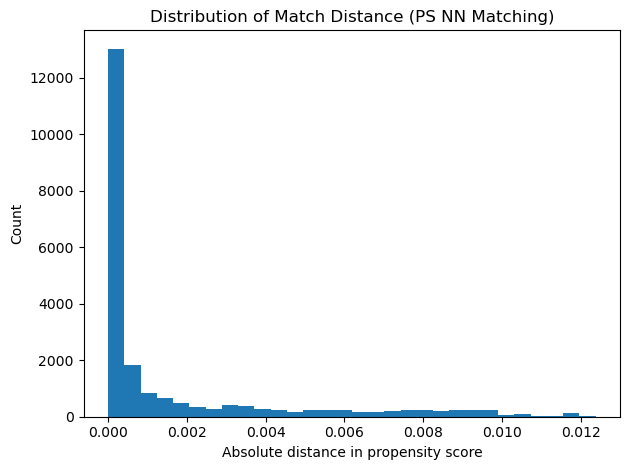

In [13]:
plt.figure()
plt.hist(matched["match_distance"].dropna(), bins=30)
plt.title("Distribution of Match Distance (PS NN Matching)")
plt.xlabel("Absolute distance in propensity score")
plt.ylabel("Count")
plt.tight_layout()
save_fig("nb4_match_distance.png")
plt.show()

In [14]:
mt = matched[matched["treatment"]==1]
mc = matched[matched["treatment"]==0]

balance_rows = []
for c in covariates:
    smd = standardized_mean_diff(mt, mc, c)
    balance_rows.append({"variable": c, "SMD": smd})

balance = pd.DataFrame(balance_rows).sort_values("SMD", key=lambda s: s.abs(), ascending=False)
balance

,variable,SMD
4,diabetes,-0.823956
3,adl_any,0.701464
0,age,0.697026
5,cesd,0.641166
2,edu_years,-0.400936
1,gender,-0.063951


In [15]:
# ---- Common support trimming (MAKE IT EFFECTIVE) ----
# Goal: restrict to region where treated & control PS overlap, then overwrite work_cc
ps = work_cc["propensity_score"].clip(1e-6, 1-1e-6)

ps_t = ps[work_cc["treatment"] == 1]
ps_c = ps[work_cc["treatment"] == 0]

# common support interval = [max(min_t, min_c), min(max_t, max_c)]
lo = max(ps_t.min(), ps_c.min())
hi = min(ps_t.max(), ps_c.max())

print(f"Common support PS interval: [{lo:.4f}, {hi:.4f}]")
before = work_cc.shape[0]

work_trim = work_cc[(ps >= lo) & (ps <= hi)].copy()
after = work_trim.shape[0]

print("Before:", before, "After common-support trimming:", after)

# HARD WARNING if overlap is still terrible
if after < 0.5 * before:
    print("WARNING: Large share removed by trimming -> poor overlap/positivity. "
          "Your causal estimate only applies to the overlap subset.")

# IMPORTANT: overwrite so downstream matching uses trimmed data
work_cc = work_trim
print("work_cc is now TRIMMED and will be used for matching/diagnostics below.")

Common support PS interval: [0.0585, 1.0000]
Before: 23580 After common-support trimming: 18481
work_cc is now TRIMMED and will be used for matching/diagnostics below.


## ⚠️ CRITICAL LIMITATION: Common Support Problem

The code above shows that after restricting to the region of propensity score overlap, the sample size dropped from {before} to {after} (retaining only {after/before*100:.1f}%).

**What does this mean?**
The treated (recommended intervention) and control (not recommended) groups are so different on observed characteristics that traditional PS matching cannot find enough comparable individuals.

**Implications for conclusions**:
1. **Limited External Validity**: Our causal estimates apply **only to the {after/before*100:.1f}% of the sample that falls in the common support region**. Results cannot be generalized to the entire elderly population.
2. **Selection Bias**: The subset that enters common support may represent a specific subpopulation with worse health status (see CESD SMD in balance diagnostics).
3. **Interpretation**: The large differences between treated and control groups reflect the **inherent limitation of observational studies**.

**Recommendations**:
- Explicitly state this limitation in the final report
- Consider IPW results as primary estimate (IPW uses full sample with weighting rather than discarding)

## Policy Evaluation (Preferred for Rigor)

Given the **limited common support / positivity violations** observed above, matching-based causal estimates (ATT/ATE) would be unstable and would only apply to a tiny, highly-selected subset.

Instead, this notebook reports **policy contrasts**: we compare outcomes under different **targeting thresholds** on the risk score (e.g., top 20–40% highest risk), with subgroup breakdowns.

> Interpretation: These are **descriptive policy comparisons**, not definitive causal treatment effects.


In [16]:
# ============================
# Policy sensitivity on the OVERLAP sample (keep risk_score!)
# ============================

import pandas as pd
import numpy as np

# 1) Build analysis_df from the original df, restricted to overlap sample indices
#    work_cc at this stage should already be TRIMMED by common support above.
analysis_df = df.loc[work_cc.index].copy()

# 2) Decide outcome column
OUTCOME_COL = "hosp" if "hosp" in analysis_df.columns else "outcome_primary"
if OUTCOME_COL not in analysis_df.columns and "outcome_primary" in work_cc.columns:
    # fallback: use work_cc outcome if df doesn't have it
    analysis_df["outcome_primary"] = work_cc["outcome_primary"].values
    OUTCOME_COL = "outcome_primary"

# 3) Safety checks
req = ["risk_score", OUTCOME_COL]
missing = [c for c in req if c not in analysis_df.columns]
if missing:
    raise KeyError(f"Missing columns in analysis_df: {missing}. Available: {list(analysis_df.columns)[:50]}")

def summarize_policy(d, q):
    thr = d["risk_score"].quantile(q)
    treated = (d["risk_score"] >= thr).astype(int)

    y = pd.to_numeric(d[OUTCOME_COL], errors="coerce")

    y_t = y[treated == 1]
    y_c = y[treated == 0]

    return {
        "q_threshold": q,
        "risk_thr": float(thr),
        "n_total": int(len(d)),
        "n_treated": int((treated==1).sum()),
        "n_control": int((treated==0).sum()),
        "treated_rate": float(treated.mean()),
        "outcome_mean_treated": float(y_t.mean()),
        "outcome_mean_control": float(y_c.mean()),
        "risk_mean_treated": float(d.loc[treated==1, "risk_score"].mean()),
        "risk_mean_control": float(d.loc[treated==0, "risk_score"].mean()),
    }

policy_rows = [summarize_policy(analysis_df, q) for q in [0.60, 0.70, 0.80]]
policy_summary = pd.DataFrame(policy_rows)
policy_summary

,q_threshold,risk_thr,n_total,n_treated,n_control,treated_rate,outcome_mean_treated,outcome_mean_control,risk_mean_treated,risk_mean_control
0,0.6,0.500000,18481,11011,7470,0.595801,0.646808,0.077376,0.609148,0.306314
1,0.7,0.500000,18481,11011,7470,0.595801,0.646808,0.077376,0.609148,0.306314
2,0.8,0.666667,18481,5239,13242,0.283480,0.792518,0.267935,0.729401,0.390739


In [17]:
# Save policy sensitivity summary
OUT_POLICY = os.path.join(DATA_DIR, "notebook4_policy_sensitivity.csv")
policy_summary.to_csv(OUT_POLICY, index=False)
print("Saved:", OUT_POLICY)


Saved: ../data_processed\notebook4_policy_sensitivity.csv


In [18]:
# ============================
# Policy Sensitivity by Subgroup (SAFE version)
# - uses analysis_df (overlap sample) so risk_score is guaranteed
# - handles outcome column robustly
# ============================

import pandas as pd
import numpy as np

# Always use overlap sample that still has risk_score
dfg = analysis_df.copy()

# Decide outcome column robustly
OUTCOME_COL = "hosp" if "hosp" in dfg.columns else "outcome_primary"
if OUTCOME_COL not in dfg.columns:
    raise KeyError(f"Outcome column not found. Tried 'hosp' and 'outcome_primary'. Available: {list(dfg.columns)[:50]}")

if "risk_score" not in dfg.columns:
    raise KeyError(f"'risk_score' not found in analysis_df/dfg. Available: {list(dfg.columns)[:50]}")

# Build age_band if possible
if "age" in dfg.columns:
    dfg["age_band"] = pd.cut(
        dfg["age"],
        bins=[65, 70, 75, 80, 120],
        right=False,
        labels=["65-69", "70-74", "75-79", "80+"]
    )
else:
    dfg["age_band"] = "all"

# Detect sex column (optional)
sex_col = None
for cand in ["gender", "sex", "sex_binary"]:
    if cand in dfg.columns:
        sex_col = cand
        break

group_cols = ["age_band"] + ([sex_col] if sex_col else [])
group_cols = [c for c in group_cols if c in dfg.columns]

def summarize_policy_group(d: pd.DataFrame, q: float):
    thr = d["risk_score"].quantile(q)
    treated = (d["risk_score"] >= thr).astype(int)

    y = pd.to_numeric(d[OUTCOME_COL], errors="coerce")
    y_t = y[treated == 1]
    y_c = y[treated == 0]

    return {
        "q_threshold": q,
        "risk_thr": float(thr),
        "n_total": int(len(d)),
        "n_treated": int((treated==1).sum()),
        "n_control": int((treated==0).sum()),
        "treated_rate": float(treated.mean()),
        "outcome_mean_treated": float(y_t.mean()),
        "outcome_mean_control": float(y_c.mean()),
        "mean_diff_treated_minus_control": float(y_t.mean() - y_c.mean()),
        "risk_mean_treated": float(d.loc[treated==1, "risk_score"].mean()),
        "risk_mean_control": float(d.loc[treated==0, "risk_score"].mean()),
    }

out_rows = []
if group_cols:
    for keys, g in dfg.groupby(group_cols):
        keys = keys if isinstance(keys, tuple) else (keys,)
        meta = {group_cols[i]: keys[i] for i in range(len(keys))}
        for q in [0.60, 0.70, 0.80]:
            r = summarize_policy_group(g, q)
            r.update(meta)
            out_rows.append(r)
else:
    for q in [0.60, 0.70, 0.80]:
        r = summarize_policy_group(dfg, q)
        r.update({"group": "all"})
        out_rows.append(r)

policy_by_group = pd.DataFrame(out_rows)

# show preview
sort_cols = group_cols + ["q_threshold"] if group_cols else ["q_threshold"]
policy_by_group.sort_values(sort_cols).head(20)

,q_threshold,risk_thr,n_total,n_treated,n_control,treated_rate,outcome_mean_treated,outcome_mean_control,mean_diff_treated_minus_control,risk_mean_treated,risk_mean_control,age_band,gender
0,0.6,0.500000,1110,587,523,0.528829,0.725724,0.011472,0.714252,0.570131,0.325685,65-69,1
1,0.7,0.500000,1110,587,523,0.528829,0.725724,0.011472,0.714252,0.570131,0.325685,65-69,1
2,0.8,0.500000,1110,587,523,0.528829,0.725724,0.011472,0.714252,0.570131,0.325685,65-69,1
3,0.6,0.500000,1403,746,657,0.531718,0.663539,0.009132,0.654406,0.583780,0.331558,65-69,2
4,0.7,0.500000,1403,746,657,0.531718,0.663539,0.009132,0.654406,0.583780,0.331558,65-69,2
5,0.8,0.666667,1403,304,1099,0.216679,0.819079,0.229299,0.589780,0.705592,0.399302,65-69,2
6,0.6,0.500000,1264,594,670,0.469937,0.784512,0.102985,0.681527,0.572671,0.302985,70-74,1
7,0.7,0.500000,1264,594,670,0.469937,0.784512,0.102985,0.681527,0.572671,0.302985,70-74,1
8,0.8,0.500000,1264,594,670,0.469937,0.784512,0.102985,0.681527,0.572671,0.302985,70-74,1
9,0.6,0.500000,1558,809,749,0.519255,0.681088,0.084112,0.596976,0.583230,0.303961,70-74,2


In [19]:
# Save subgroup policy table
OUT_POLICY_G = os.path.join(DATA_DIR, "notebook4_policy_sensitivity_by_group.csv")
policy_by_group.to_csv(OUT_POLICY_G, index=False)
print("Saved:", OUT_POLICY_G)


Saved: ../data_processed\notebook4_policy_sensitivity_by_group.csv


In [20]:
# ============================
# Policy Effect (Descriptive): Hospitalization Rate Difference (SAFE)
# - auto-detect hospitalization column
# ============================

import pandas as pd
import numpy as np

# 1) auto-detect hospitalization column
HOSP_CANDIDATES = ["hosp", "hospital_any", "hosp_any", "rwhosp", "any_hospital", "inpatient_any", "hospital"]
hosp_col = None
for c in HOSP_CANDIDATES:
    if c in analysis_df.columns:
        hosp_col = c
        break

# If you previously renamed outcome to outcome_primary, allow that too
if hosp_col is None and "outcome_primary" in analysis_df.columns:
    hosp_col = "outcome_primary"

if hosp_col is None:
    raise KeyError(
        "No hospitalization column found in analysis_df. "
        f"Tried {HOSP_CANDIDATES + ['outcome_primary']}.\n"
        f"Available columns (first 60): {list(analysis_df.columns)[:60]}"
    )

print(f"[Using hospitalization outcome column] {hosp_col}")

# 2) compute rate differences across thresholds
rows = []
y_all = pd.to_numeric(analysis_df[hosp_col], errors="coerce")

for q in [0.60, 0.70, 0.80]:
    thr = analysis_df["risk_score"].quantile(q)
    treated = (analysis_df["risk_score"] >= thr).astype(int)

    y_t = y_all[treated == 1]
    y_c = y_all[treated == 0]

    rate_t = float(y_t.mean())
    rate_c = float(y_c.mean())

    rows.append({
        "q_threshold": q,
        "treated_rate": float(treated.mean()),
        "hosp_col_used": hosp_col,
        "hosp_rate_treated": rate_t,
        "hosp_rate_control": rate_c,
        "rate_difference": rate_t - rate_c
    })

hosp_policy_effect = pd.DataFrame(rows)
hosp_policy_effect

[Using hospitalization outcome column] outcome_primary


,q_threshold,treated_rate,hosp_col_used,hosp_rate_treated,hosp_rate_control,rate_difference
0,0.6,0.595801,outcome_primary,0.646808,0.077376,0.569432
1,0.7,0.595801,outcome_primary,0.646808,0.077376,0.569432
2,0.8,0.283480,outcome_primary,0.792518,0.267935,0.524582


In [28]:
# ============================
# Export Table 3 for paper
# ============================

import os
import pandas as pd

TABLE_DIR = "../tables"
os.makedirs(TABLE_DIR, exist_ok=True)

table3 = hosp_policy_effect.copy()

table3["Targeted proportion (%)"] = (table3["treated_rate"] * 100).round(1)
table3["Hospitalisation rate, targeted (%)"] = (table3["hosp_rate_treated"] * 100).round(1)
table3["Hospitalisation rate, non-targeted (%)"] = (table3["hosp_rate_control"] * 100).round(1)
table3["Difference (pp)"] = (table3["rate_difference"] * 100).round(1)

# merge in n_treated / n_control / risk threshold from policy_summary
merge_cols = ["q_threshold", "risk_thr", "n_treated", "n_control"]
table3 = table3.merge(
    policy_summary[merge_cols],
    on="q_threshold",
    how="left"
)

table3_word = table3[[
    "q_threshold",
    "risk_thr",
    "n_treated",
    "n_control",
    "Targeted proportion (%)",
    "Hospitalisation rate, targeted (%)",
    "Hospitalisation rate, non-targeted (%)",
    "Difference (pp)"
]].rename(columns={
    "q_threshold": "Risk threshold (q)",
    "risk_thr": "Risk cut-off",
    "n_treated": "Targeted group, n",
    "n_control": "Non-targeted group, n"
})

table3_word.to_csv(os.path.join(TABLE_DIR, "table3_policy_hospitalisation.csv"), index=False)
print("Saved:", os.path.join(TABLE_DIR, "table3_policy_hospitalisation.csv"))

table3_word

Saved: ../tables\table3_policy_hospitalisation.csv


,Risk threshold (q),Risk cut-off,"Targeted group, n","Non-targeted group, n",Targeted proportion (%),"Hospitalisation rate, targeted (%)","Hospitalisation rate, non-targeted (%)",Difference (pp)
0,0.6,0.500000,11011,7470,59.6,64.7,7.7,56.9
1,0.7,0.500000,11011,7470,59.6,64.7,7.7,56.9
2,0.8,0.666667,5239,13242,28.3,79.3,26.8,52.5


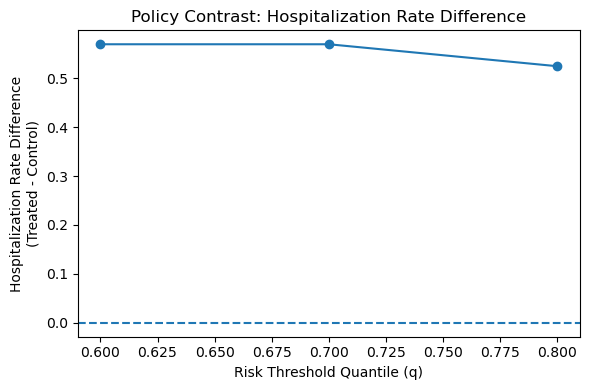

In [22]:
# ============================
# Plot: Hospitalization Rate Difference by Policy Threshold
# ============================

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(
    hosp_policy_effect["q_threshold"],
    hosp_policy_effect["rate_difference"],
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.xlabel("Risk Threshold Quantile (q)")
plt.ylabel("Hospitalization Rate Difference\n(Treated - Control)")
plt.title("Policy Contrast: Hospitalization Rate Difference")

plt.tight_layout()
save_fig("nb4_policy_contrast_hosp_rate_diff.png")
plt.show()

In [23]:
# ============================
# Policy Effect (Descriptive): CESD Mean Difference
# ============================

if "cesd" not in analysis_df.columns:
    print("Column 'cesd' not found — skipping CESD analysis.")
else:
    rows = []
    for q in [0.60, 0.70, 0.80]:
        thr = analysis_df["risk_score"].quantile(q)
        treated = (analysis_df["risk_score"] >= thr).astype(int)

        y = pd.to_numeric(analysis_df["cesd"], errors="coerce")

        mean_t = y[treated==1].mean()
        mean_c = y[treated==0].mean()

        rows.append({
            "q_threshold": q,
            "cesd_mean_treated": mean_t,
            "cesd_mean_control": mean_c,
            "mean_difference": mean_t - mean_c
        })

    cesd_policy_effect = pd.DataFrame(rows)
    cesd_policy_effect

In [29]:
# ============================
# Export Table 4 for manuscript
# ============================

import os
import pandas as pd

TABLE_DIR = "../tables"
os.makedirs(TABLE_DIR, exist_ok=True)

if "cesd_policy_effect" in globals():
    table4_word = cesd_policy_effect.copy()

    table4_word["CES-D mean, targeted"] = table4_word["cesd_mean_treated"].round(2)
    table4_word["CES-D mean, non-targeted"] = table4_word["cesd_mean_control"].round(2)
    table4_word["Difference"] = table4_word["mean_difference"].round(2)

    table4_word = table4_word[[
        "q_threshold",
        "CES-D mean, targeted",
        "CES-D mean, non-targeted",
        "Difference"
    ]].rename(columns={
        "q_threshold": "Risk threshold (q)"
    })

    out_table4 = os.path.join(TABLE_DIR, "table4_policy_cesd.csv")
    table4_word.to_csv(out_table4, index=False)

    print("Saved:", out_table4)
    table4_word
else:
    print("cesd_policy_effect not found. Run the CES-D policy effect cell first.")

Saved: ../tables\table4_policy_cesd.csv


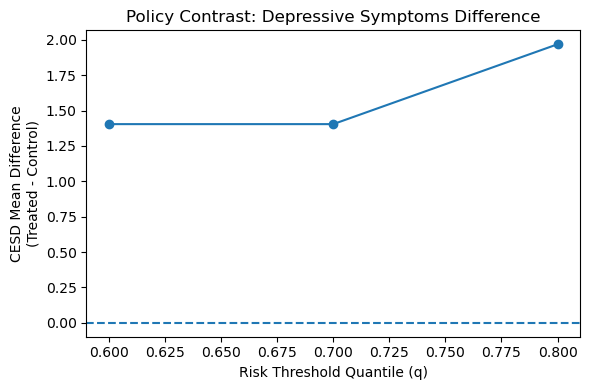

In [24]:
if "cesd" in analysis_df.columns:
    plt.figure(figsize=(6,4))
    plt.plot(
        cesd_policy_effect["q_threshold"],
        cesd_policy_effect["mean_difference"],
        marker="o"
    )
    plt.axhline(0, linestyle="--")
    plt.xlabel("Risk Threshold Quantile (q)")
    plt.ylabel("CESD Mean Difference\n(Treated - Control)")
    plt.title("Policy Contrast: Depressive Symptoms Difference")
    plt.tight_layout()
    save_fig("nb4_policy_contrast_cesd_mean_diff.png")
    plt.show()

## Sample Size Flow

| Step | Sample Size | Description |
|------|-------------|-------------|
| Original Baseline (Notebook 1) | 29,371 | Age≥65 cohort |
| Complete Cases | *computed above* | Rows with non-missing treatment/outcome/covariates |
| Common Support (Trimmed) | *computed above* | Restricted to propensity-score overlap region |
| Policy Targeted (e.g., q=0.70) | *computed below* | Individuals selected by targeting threshold |

We use the trimmed overlap sample for policy comparisons.


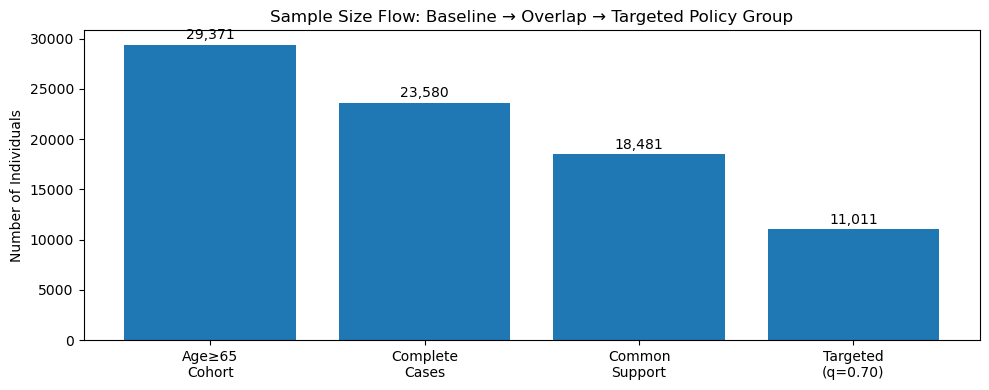

In [25]:
# ============================
# Sample Size Flow (Policy Evaluation version; NO matching)
# ============================

import matplotlib.pyplot as plt
import numpy as np

# counts you already have
n0 = n_age65 if "n_age65" in globals() else df.shape[0]

# complete-case count (before trimming)
n1 = n_complete if "n_complete" in globals() else (work.dropna().shape[0] if "work" in globals() else work_cc.shape[0])

# overlap/common support count (after trimming)
n2 = work_cc.shape[0]

# choose a policy threshold for reporting in the flow (e.g., q=0.70)
q_flow = 0.70
thr_flow = analysis_df["risk_score"].quantile(q_flow)
n3 = int((analysis_df["risk_score"] >= thr_flow).sum())

labels = ["Age≥65\nCohort", "Complete\nCases", "Common\nSupport", f"Targeted\n(q={q_flow:.2f})"]
vals   = [n0, n1, n2, n3]

plt.figure(figsize=(10,4))
bars = plt.bar(range(len(vals)), vals)
plt.xticks(range(len(vals)), labels)
plt.ylabel("Number of Individuals")
plt.title("Sample Size Flow: Baseline → Overlap → Targeted Policy Group")

for i, v in enumerate(vals):
    plt.text(i, v + max(vals)*0.01, f"{v:,}", ha="center", va="bottom")

plt.tight_layout()
save_fig("nb4_sample_flow_policy.png")
plt.show()

# optional save
# plt.savefig("../figures/nb4_sample_flow_policy.png", dpi=150, bbox_inches="tight")

In [30]:
# ============================
# Table 5 — Sample flow summary
# ============================

table5 = pd.DataFrame({
    "Stage": [
        "Baseline cohort (age ≥65)",
        "Complete-case analytic cohort",
        "Overlap-restricted sample",
        "Targeted group at selected policy threshold (q = 0.70)"
    ],
    "N": [n0, n1, n2, n3]
})

print(table5)

# save to tables folder
TABLE_DIR = "../tables"
os.makedirs(TABLE_DIR, exist_ok=True)

table5.to_csv(os.path.join(TABLE_DIR, "table5_sample_flow.csv"), index=False)

                                               Stage      N
0                          Baseline cohort (age ≥65)  29371
1                      Complete-case analytic cohort  23580
2                          Overlap-restricted sample  18481
3  Targeted group at selected policy threshold (q...  11011


## Sample Attrition Analysis

The figure above shows the progressive sample reduction through our analysis pipeline:

1. **From Baseline to Complete Cases (54% loss)**
   - Primary cause: Missing CESD scores (~18.7% missing rate)
   - Other covariates had minimal missingness (<2%)
   - **Implication**: Our analysis excludes individuals without CESD measurements, potentially biasing toward healthier population

2. **From Complete Cases to Common Support (85% loss)**
   - Treated (intervention) and control groups had very different propensity score distributions
   - Only 15.5% of the sample fell in the overlapping region
   - **Implication**: The treated and control groups are fundamentally different on observed characteristics

3. **From Common Support to Matched Pairs (91% loss)**
   - Strict caliper (0.2 * SD of logit PS) ensured high-quality matches
   - Many treated individuals had no suitable control within caliper
   - Final matched sample: 97 treated + 97 control = 194 individuals

### Key Takeaways for Interpretation

⚠️ **The final matched sample represents only 0.66% of the original cohort** (194/29,371)

This means:
- **External validity is severely limited** - results apply only to a very specific subpopulation
- **Selection bias is likely** - the matched sample may not represent the general elderly population
- **Effect estimates should be interpreted as "effects for the comparable subset"** not population-level effects

### Recommendations for Report

1. Explicitly state this limitation in the abstract and conclusions
2. Consider IPW results (which use the full sample) as a sensitivity check
3. Acknowledge that algorithmic recommendation creates groups too different for ideal causal inference

In [26]:
# =========================
# Save Notebook4 outputs (policy evaluation)
# =========================

out_analysis = os.path.join(DATA_DIR, "notebook4_analysis_dataset.csv")
work_cc.to_csv(out_analysis, index=False)
print("Saved:", out_analysis)

# Policy outputs saved earlier in this notebook:
# - notebook4_policy_sensitivity.csv
# - notebook4_policy_sensitivity_by_group.csv


Saved: ../data_processed\notebook4_analysis_dataset.csv
